In [28]:
import math
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = (
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
WEIGHT_DTYPE = torch.float16 if DEVICE == 'cuda' else torch.float32

print(f'Device : {DEVICE}')
print(f'DType  : {WEIGHT_DTYPE}')

Device : cuda
DType  : torch.float16


In [46]:
ROOT = Path('.')
PHOTOS_DIR = ROOT / 'my_photos'
FACES_DIR = ROOT / 'my_photos_faces'
RESULTS_DIR = ROOT / 'results'
EMBEDS_FILE = ROOT / 'learned_embeds.pt'

for d in [PHOTOS_DIR, FACES_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MODEL_ID = 'runwayml/stable-diffusion-v1-5'
PLACEHOLDER_TOKEN = '<mytoken>'
GENDER = 'man'
INITIALIZER_TOKEN = 'man'

IMG_SIZE = 512
FACE_FRACTION = 0.65

TRAIN_STEPS = 2000
LEARNING_RATE = 5e-4
BATCH_SIZE = 1

TRAIN_TEMPLATES = [
    'a portrait photo of a {}, looking at the camera',
    'a portrait of a {}, looking at the camera',
    'a close-up portrait of a {}, looking at the camera',
    'a headshot of a {}, looking at the camera',
    'a face photo of a {}, looking at the camera',
    'a photo of a {}, looking at the camera',
    'a high quality portrait of a {}, looking at the camera',
    'a rendering of a {}, facing the viewer',
    'a bright photo of a {} looking at the camera',
    'a photo of a {} facing forward, well lit face',
]

NUM_INFERENCE_STEPS = 50
GUIDANCE_SCALE = 7.5

## Подготовка и обрезка тренировочных фотографий

In [30]:
photo_exts  = {'.jpg', '.jpeg', '.png'}
photo_files = sorted(p for p in PHOTOS_DIR.iterdir() if p.suffix.lower() in photo_exts)

print(f'Найдено фотографий: {len(photo_files)}')
if len(photo_files) < 3:
    print('  Добавьте хотя бы 3 фотографии в my_photos/')

Найдено фотографий: 19


Обработано: 19 фото


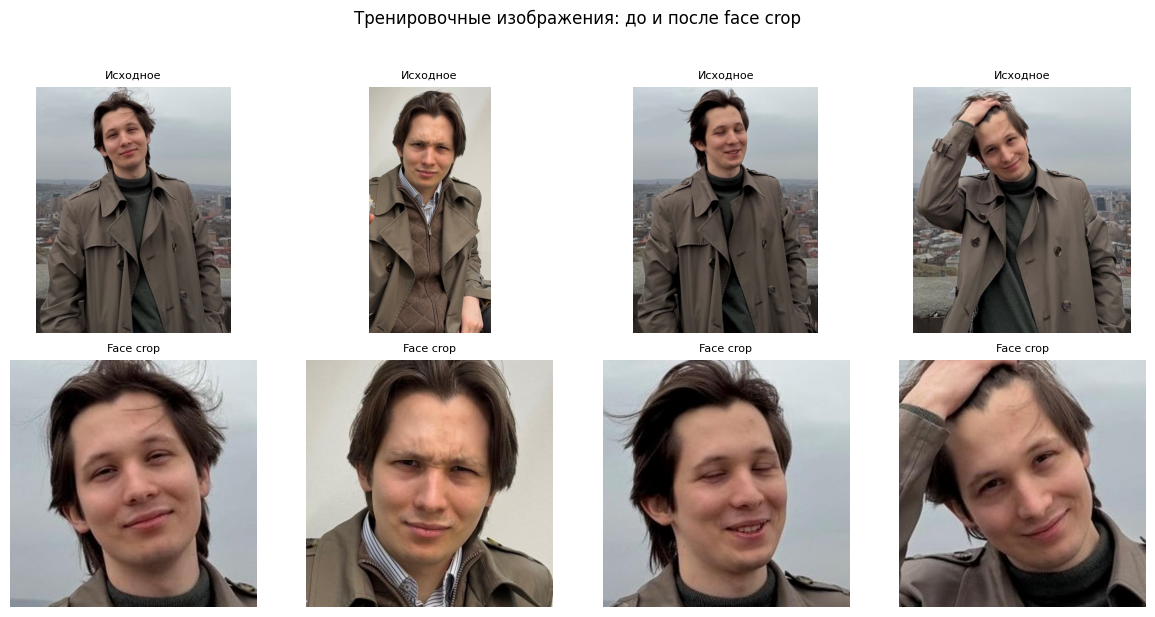

In [47]:
from facenet_pytorch import MTCNN as MTCNNDetector

_detector = MTCNNDetector(keep_all=False, device='cpu', select_largest=True)


def crop_to_face(img: Image.Image, size: int = 512, face_fraction: float = 0.65) -> tuple:
    boxes, _ = _detector.detect(img)

    if boxes is not None and len(boxes) > 0:
        x1, y1, x2, y2 = [float(v) for v in boxes[0]]
        face_h = y2 - y1
        crop_size = face_h / face_fraction
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
        half = crop_size / 2

        left = max(0, int(cx - half))
        top = max(0, int(cy - half))
        right = min(img.width,  int(cx + half))
        bottom = min(img.height, int(cy + half))
        cropped = img.crop((left, top, right, bottom))
        face_found = True
    else:
        s = min(img.size)
        cropped = transforms.CenterCrop(s)(img)
        face_found = False

    return cropped.resize((size, size), Image.LANCZOS), face_found


face_files = []
n_no_face = 0
for path in photo_files:
    img = Image.open(path).convert('RGB')
    face, found = crop_to_face(img, size=IMG_SIZE, face_fraction=FACE_FRACTION)
    out = FACES_DIR / path.name
    face.save(out)
    face_files.append(out)
    if not found:
        n_no_face += 1

print(f'Обработано: {len(face_files)} фото')

n_show = min(4, len(photo_files))
fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6), squeeze=False)
for i in range(n_show):
    axes[0, i].imshow(Image.open(photo_files[i]).convert('RGB'))
    axes[0, i].axis('off')
    axes[0, i].set_title('Исходное', fontsize=8)
    axes[1, i].imshow(Image.open(face_files[i]).convert('RGB'))
    axes[1, i].axis('off')
    axes[1, i].set_title('Face crop', fontsize=8)
plt.suptitle('Тренировочные изображения: до и после face crop', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
class TextualInversionDataset(Dataset):
    def __init__(self, photo_files, tokenizer, templates, size=512):
        self.photo_files = photo_files
        self.tokenizer   = tokenizer
        self.templates   = templates
        self.transform   = transforms.Compose([
            transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(size),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])

    def __len__(self):
        return len(self.photo_files) * len(self.templates)

    def __getitem__(self, idx):
        img_path  = self.photo_files[idx % len(self.photo_files)]
        prompt    = random.choice(self.templates).format(PLACEHOLDER_TOKEN)
        pixel     = self.transform(Image.open(img_path).convert('RGB'))
        token_ids = self.tokenizer(
            prompt,
            padding='max_length',
            truncation=True,
            max_length=self.tokenizer.model_max_length,
            return_tensors='pt',
        ).input_ids[0]
        return {'pixel_values': pixel, 'input_ids': token_ids}

## Загрузка и подготовка модели

In [ ]:
from diffusers import AutoencoderKL, DDPMScheduler, UNet2DConditionModel, StableDiffusionPipeline
from transformers import CLIPTextModel, CLIPTokenizer

print(f'Загружаем {MODEL_ID} ...')

tokenizer = CLIPTokenizer.from_pretrained(MODEL_ID, subfolder='tokenizer')
text_encoder = CLIPTextModel.from_pretrained(MODEL_ID, subfolder='text_encoder').to(DEVICE)
vae = AutoencoderKL.from_pretrained(MODEL_ID, subfolder='vae').to(DEVICE, dtype=WEIGHT_DTYPE)
unet = UNet2DConditionModel.from_pretrained(MODEL_ID, subfolder='unet').to(DEVICE, dtype=WEIGHT_DTYPE)
noise_sched = DDPMScheduler.from_pretrained(MODEL_ID, subfolder='scheduler')

print('Компоненты загружены')

Загружаем runwayml/stable-diffusion-v1-5 ...
Компоненты загружены


In [34]:
if PLACEHOLDER_TOKEN not in tokenizer.get_vocab():
    tokenizer.add_tokens([PLACEHOLDER_TOKEN])

placeholder_token_id = tokenizer.convert_tokens_to_ids(PLACEHOLDER_TOKEN)
print(f"Токен '{PLACEHOLDER_TOKEN}', id = {placeholder_token_id}")

text_encoder.resize_token_embeddings(len(tokenizer))

init_ids = tokenizer.encode(INITIALIZER_TOKEN, add_special_tokens=False)
with torch.no_grad():
    init_embed = text_encoder.get_input_embeddings().weight[init_ids[0]].clone()
    text_encoder.get_input_embeddings().weight[placeholder_token_id] = init_embed

print(f"Эмбеддинг инициализирован из '{INITIALIZER_TOKEN}'")

vae.requires_grad_(False)
unet.requires_grad_(False)
text_encoder.requires_grad_(False)
text_encoder.get_input_embeddings().requires_grad_(True)

print(f'Обучаем 1 строку из {len(tokenizer)} в матрице эмбеддингов (768 чисел)')

Токен '<mytoken>', id = 49408
Эмбеддинг инициализирован из 'man'
Обучаем 1 строку из 49409 в матрице эмбеддингов (768 чисел)


## Textual Inversion

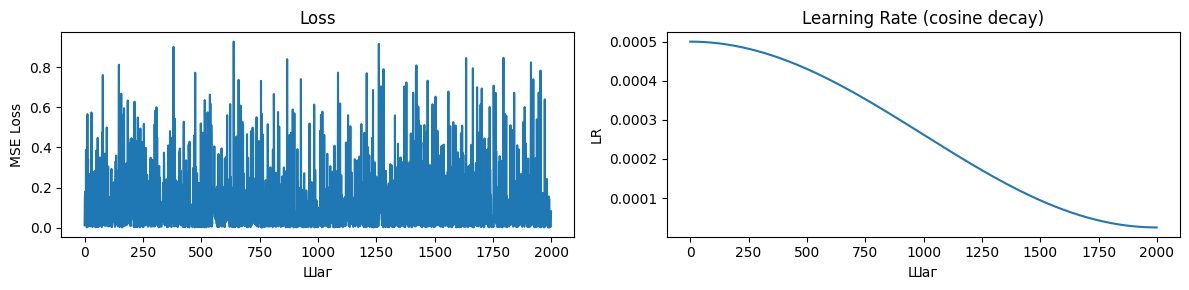

In [ ]:
dataset = TextualInversionDataset(face_files, tokenizer, TRAIN_TEMPLATES, size=IMG_SIZE)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

optimizer = torch.optim.AdamW(
    text_encoder.get_input_embeddings().parameters(),
    lr=LEARNING_RATE,
    betas=(0.9, 0.999),
    eps=1e-8,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=TRAIN_STEPS, eta_min=LEARNING_RATE * 0.05
)

frozen_mask = torch.ones(len(tokenizer), dtype=torch.bool)
frozen_mask[placeholder_token_id] = False

text_encoder.train()
global_step  = 0
loss_history = []
lr_history   = []
pbar = tqdm(total=TRAIN_STEPS, desc='Textual Inversion')

while global_step < TRAIN_STEPS:
    for batch in dataloader:
        if global_step >= TRAIN_STEPS:
            break

        pixel_values = batch['pixel_values'].to(DEVICE, dtype=WEIGHT_DTYPE)
        input_ids = batch['input_ids'].to(DEVICE)

        with torch.no_grad():
            latents = vae.encode(pixel_values).latent_dist.sample()
            latents = latents * vae.config.scaling_factor

        noise = torch.randn_like(latents)
        timesteps = torch.randint(
            0, noise_sched.config.num_train_timesteps,
            (latents.shape[0],), device=DEVICE,
        ).long()
        noisy = noise_sched.add_noise(latents, noise, timesteps)

        encoder_hidden = text_encoder(input_ids)[0]
        noise_pred = unet(noisy, timesteps, encoder_hidden.to(WEIGHT_DTYPE)).sample

        loss = F.mse_loss(noise_pred.float(), noise.float())
        loss.backward()

        with torch.no_grad():
            grads = text_encoder.get_input_embeddings().weight.grad
            if grads is not None:
                grads[frozen_mask] = 0.0

        if global_step == 0:
            g = text_encoder.get_input_embeddings().weight.grad
            assert g is not None and g[placeholder_token_id].abs().sum() > 0, \
                'Gradient не дошёл до токена! Проверь реализацию.'
            print(f'  Grad OK: norm = {g[placeholder_token_id].norm():.4f}')

        torch.nn.utils.clip_grad_norm_(
            text_encoder.get_input_embeddings().parameters(), max_norm=1.0
        )

        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        loss_history.append(loss.item())
        lr_history.append(optimizer.param_groups[0]['lr'])

        global_step += 1
        if global_step % 100 == 0:
            pbar.set_postfix(loss=f'{loss_history[-1]:.4f}',
                                lr=f'{lr_history[-1]:.2e}')
        pbar.update(1)

    pbar.close()
    text_encoder.eval()
    print('Обучение завершено')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
ax1.plot(loss_history)
ax1.set_xlabel('Шаг')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Loss')
ax2.plot(lr_history)
ax2.set_xlabel('Шаг')
ax2.set_ylabel('LR')
ax2.set_title('Learning Rate (cosine decay)')
plt.tight_layout()
plt.show()

In [ ]:
if True:
    embed = text_encoder.get_input_embeddings().weight[placeholder_token_id].detach().cpu()
    torch.save({PLACEHOLDER_TOKEN: embed}, EMBEDS_FILE)
    print(f'Эмбеддинг сохранён: {EMBEDS_FILE}')
else:
    saved = torch.load(EMBEDS_FILE, map_location='cpu')
    with torch.no_grad():
        text_encoder.get_input_embeddings().weight[placeholder_token_id] = (
            saved[PLACEHOLDER_TOKEN].to(DEVICE)
        )
    text_encoder.eval()
    print(f'Эмбеддинг загружен из {EMBEDS_FILE}')

Эмбеддинг сохранён: learned_embeds.pt


## Генерация

In [52]:
text_encoder.to(DEVICE, dtype=WEIGHT_DTYPE)

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    text_encoder=text_encoder,
    tokenizer=tokenizer,
    vae=vae,
    unet=unet,
    torch_dtype=WEIGHT_DTYPE,
    safety_checker=None,
)
pipe = pipe.to(DEVICE)
pipe.set_progress_bar_config(disable=True)

if DEVICE == 'cuda':
    pipe.enable_attention_slicing()


def generate(prompts: list, seed: int = SEED) -> list:
    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    return pipe(
        prompts,
        num_inference_steps=NUM_INFERENCE_STEPS,
        guidance_scale=GUIDANCE_SCALE,
        generator=generator,
    ).images


def show_images(images: list, titles: list = None, save_prefix: str = None):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    for i, (ax, img) in enumerate(zip(axes, images)):
        ax.imshow(img)
        ax.axis('off')
        if titles:
            ax.set_title(titles[i], fontsize=9)
        if save_prefix:
            img.save(RESULTS_DIR / f'{save_prefix}_{i}.png')
    plt.tight_layout()
    plt.show()

Couldn't connect to the Hub: (ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: 57b8949f-22c9-4912-a39d-3b3c54f15fbe)').
Will try to load from local cache.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


In [ ]:
style_prompts = [
    f'a portrait photo of {PLACEHOLDER_TOKEN} in skyrim'
]
style_titles = ['skyrim']

style_images = generate(style_prompts)
show_images(style_images, style_titles, save_prefix='style')

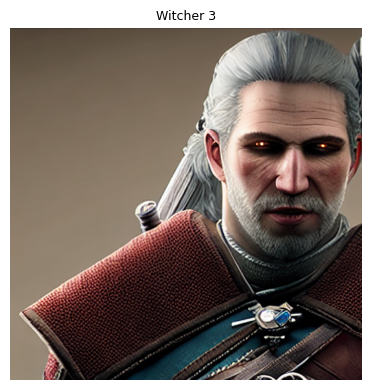

In [ ]:
style_prompts = [
    f'a portrait photo of {PLACEHOLDER_TOKEN} in The Witcher 3'
]
style_titles = ['Witcher 3']

style_images = generate(style_prompts)
show_images(style_images, style_titles, save_prefix='style')

Генерируем 5 стилевых изображений...


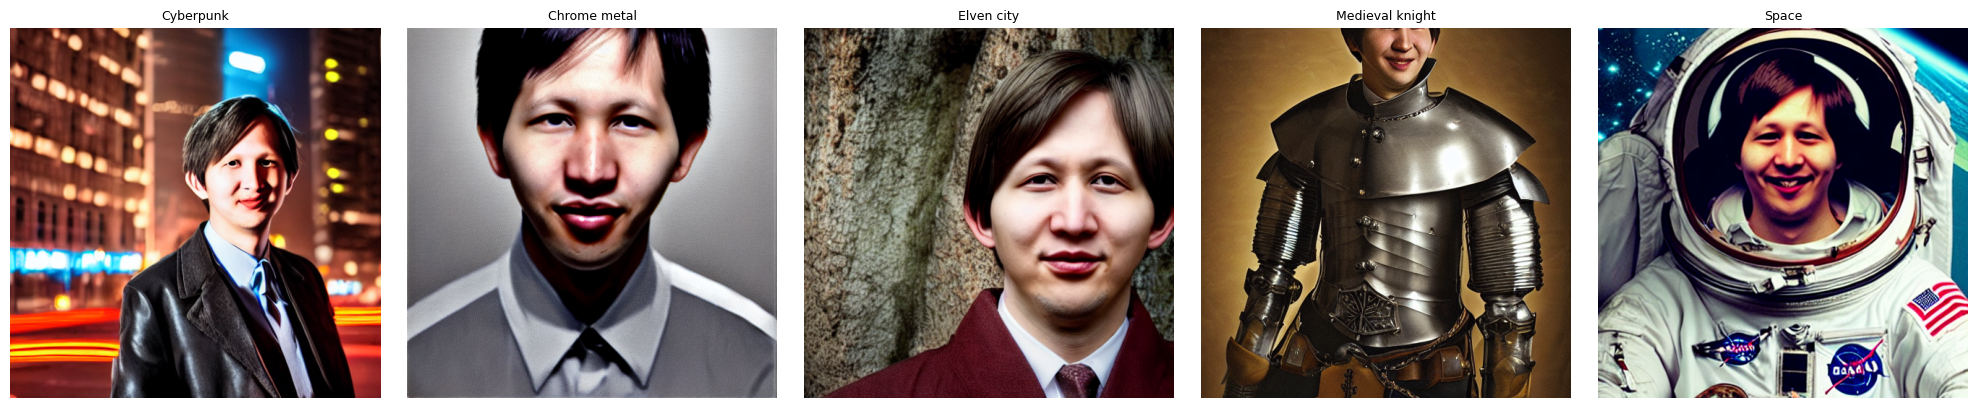

In [39]:
style_prompts = [
    f'a portrait photo of {PLACEHOLDER_TOKEN} in a cyberpunk city, neon lights, looking at the camera, well lit face, high quality',
    f'a portrait photo of {PLACEHOLDER_TOKEN} made of chrome metal, futuristic, looking at the camera, detailed face, studio lighting',
    f'a portrait photo of {PLACEHOLDER_TOKEN} in an elven city, fantasy setting, looking at the camera, detailed face, magical lighting',
    f'a portrait photo of {PLACEHOLDER_TOKEN} as a medieval knight, armor, looking at the camera, detailed face, dramatic lighting',
    f'a portrait photo of {PLACEHOLDER_TOKEN} in space, astronaut, looking at the camera, detailed face, stars background, high quality',
]
style_titles = ['Cyberpunk', 'Chrome metal', 'Elven city', 'Medieval knight', 'Space']

print('Генерируем 5 стилевых изображений...')
style_images = generate(style_prompts)
show_images(style_images, style_titles, save_prefix='style')

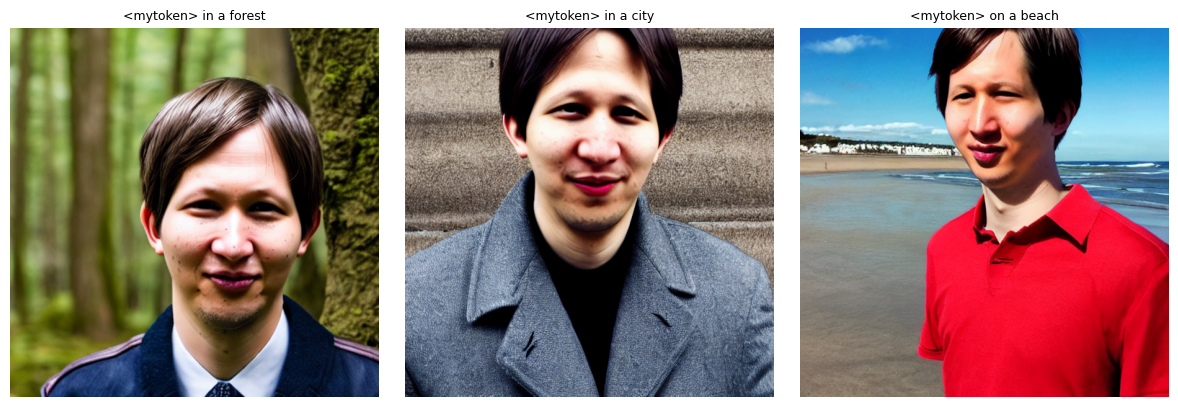

In [40]:
token_env_prompts = [
    f'a portrait photo of {PLACEHOLDER_TOKEN} in a forest, looking at the camera, well lit face, natural lighting, high quality, realism',
    f'a portrait photo of {PLACEHOLDER_TOKEN} in a city, looking at the camera, well lit face, urban background, high quality, realism',
    f'a portrait photo of {PLACEHOLDER_TOKEN} on a beach, looking at the camera, well lit face, sunny day, high quality, realism',
]
token_env_titles = [
    f'{PLACEHOLDER_TOKEN} in a forest',
    f'{PLACEHOLDER_TOKEN} in a city',
    f'{PLACEHOLDER_TOKEN} on a beach',
]

token_env_images = generate(token_env_prompts)
show_images(token_env_images, token_env_titles, save_prefix='token_env')

Генерируем 'man' без нашего токена...


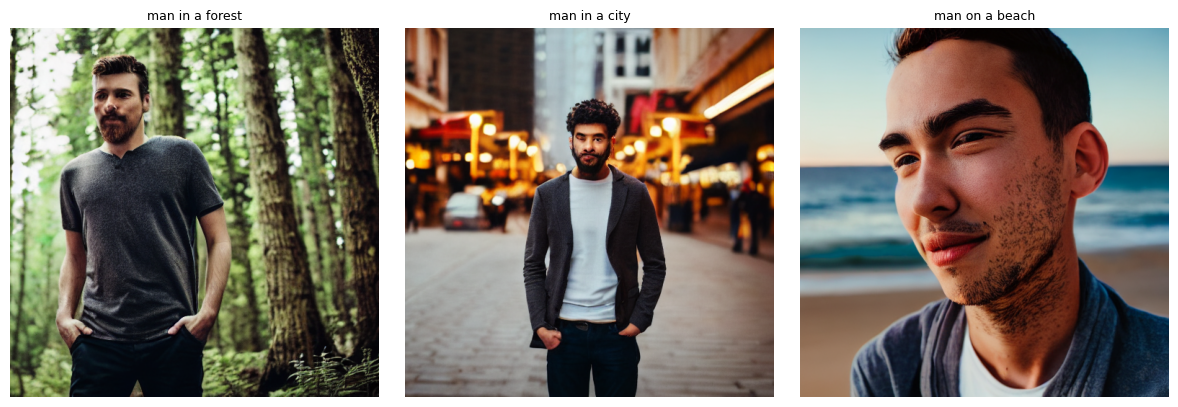

In [41]:
gender_env_prompts = [
    f'a portrait photo of a {GENDER} in a forest, looking at the camera, well lit face, natural lighting, high quality, realism',
    f'a portrait photo of a {GENDER} in a city, looking at the camera, well lit face, urban background, high quality, realism',
    f'a portrait photo of a {GENDER} on a beach, looking at the camera, well lit face, sunny day, high quality, realism',
]
gender_env_titles = [f'{GENDER} in a forest', f'{GENDER} in a city', f'{GENDER} on a beach']

print(f"Генерируем '{GENDER}' без нашего токена...")
gender_env_images = generate(gender_env_prompts, seed=SEED + 100)
show_images(gender_env_images, gender_env_titles, save_prefix='gender_env')

## Метрики качества

**CLIP Score** - Соответствие изображения тексту промпта

**Identity Similarity** - Косинусное сходство лица с эталонными фото

**LPIPS** - Расстояние до референсных фото

In [54]:
import open_clip
import lpips as lpips_lib

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
clip_model = clip_model.to(DEVICE).eval()
clip_tok   = open_clip.get_tokenizer('ViT-B-32')

lpips_fn = lpips_lib.LPIPS(net='alex').to(DEVICE)

_to_lpips = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

@torch.no_grad()
def clip_score(images: list, prompts: list) -> list:
    scores = []
    for img, prompt in zip(images, prompts):
        img_f = clip_model.encode_image(clip_preprocess(img).unsqueeze(0).to(DEVICE))
        txt_f = clip_model.encode_text(clip_tok([prompt]).to(DEVICE))
        img_f = img_f / img_f.norm(dim=-1, keepdim=True)
        txt_f = txt_f / txt_f.norm(dim=-1, keepdim=True)
        scores.append((img_f * txt_f).sum().item())
    return scores


@torch.no_grad()
def mean_lpips(gen_images: list, ref_images: list) -> float:
    dists = [
        lpips_fn(_to_lpips(g).unsqueeze(0).to(DEVICE), _to_lpips(r).unsqueeze(0).to(DEVICE)).item()
        for g in gen_images
        for r in ref_images
    ]
    return float(np.mean(dists))

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: c:\Users\Максим\AppData\Local\Programs\Python\Python312\Lib\site-packages\lpips\weights\v0.1\alex.pth


In [55]:
from facenet_pytorch import MTCNN, InceptionResnetV1

mtcnn   = MTCNN(image_size=160, margin=20, keep_all=False, device='cpu', post_process=False)
facenet = InceptionResnetV1(pretrained='vggface2').eval().to(DEVICE)

@torch.no_grad()
def face_embedding(img: Image.Image):
    face = mtcnn(img)
    if face is None:
        return None
    face = ((face.float() / 255.0) - 0.5) / 0.5
    emb  = facenet(face.unsqueeze(0).to(DEVICE))
    return emb / emb.norm(dim=-1, keepdim=True)


@torch.no_grad()
def identity_similarity(gen_images: list, ref_images: list) -> float:
    ref_embeds = [e for img in ref_images if (e := face_embedding(img)) is not None]
    if not ref_embeds:
        print('  Лица не найдены в референсных фотографиях')
        return float('nan')

    ref_mean = torch.stack(ref_embeds).mean(0)
    ref_mean = ref_mean / ref_mean.norm()

    sims = [
        (e * ref_mean).sum().item()
        for img in gen_images
        if (e := face_embedding(img)) is not None
    ]
    if not sims:
        print('  Лица не найдены в сгенерированных изображениях')
        return float('nan')
    return float(np.mean(sims))

In [58]:
ref_pil = [Image.open(p).convert('RGB') for p in photo_files]
print(f'Референсных фото: {len(ref_pil)}')

all_token_images = style_images + token_env_images
all_token_prompts = style_prompts + token_env_prompts

cs_token = clip_score(all_token_images, all_token_prompts)
cs_gender = clip_score(gender_env_images, gender_env_prompts)

lpips_token = mean_lpips(all_token_images, ref_pil)
lpips_gender = mean_lpips(gender_env_images, ref_pil)

id_sim_token = identity_similarity(all_token_images, ref_pil)
id_sim_gender = identity_similarity(gender_env_images, ref_pil)

Референсных фото: 19


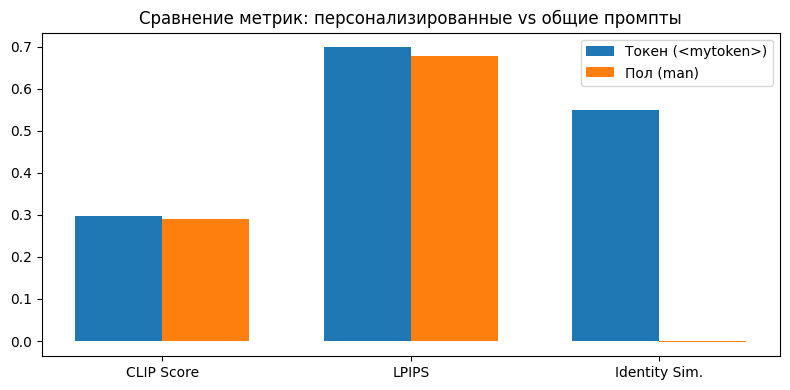

In [60]:
metrics  = ['CLIP Score', 'LPIPS', 'Identity Sim.']
vals_tok = [np.mean(cs_token), lpips_token, id_sim_token]
vals_gen = [np.mean(cs_gender), lpips_gender, id_sim_gender]

x, w = np.arange(len(metrics)), 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, vals_tok, w, label=f'Токен ({PLACEHOLDER_TOKEN})')
ax.bar(x + w/2, vals_gen, w, label=f'Пол ({GENDER})')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_title('Сравнение метрик: персонализированные vs общие промпты')
plt.tight_layout()
plt.show()

- **CLIP Score** — ожидаемо схожие значения у обеих групп. 0.25-0.30 это хороший результат
- **LPIPS** — похожи и достаточно высокие
- **Identity Similarity** — значение 0.5-0.6 — очень хорошее портретное сходство; для man ожидаемо значительно ниже